# Analysis of DBN Model for Human Action Prediction

This notebook analyses the results of a Dynamic Bayesian Network (DBN) model for human action prediction.

The model is inspired by the study *The eye in hand: predicting others’ behaviour by integrating multiple sources of information*. The aim is to examine how gaze, hand preshape, and trajectory cues influence action prediction over time.

# Imports

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [19]:
df = pd.read_csv(r"C:\Users\csras\Documents\GitHub\CognitiveRoboticsCoursework_QMULRAI2026\experiments\results.csv")
df.head()

,stage,observation,noisy_observation,small_prob,large_prob,prediction,true_target,correct,trial_id,experiment,description
0,gaze,0,0,0.550000,0.450000,0,0,1,0,all_cues_correct_small,All cues correctly indicate the small object.
1,hand,0,0,0.732558,0.267442,0,0,1,0,all_cues_correct_small,All cues correctly indicate the small object.
2,trajectory,0,0,0.925277,0.074723,0,0,1,0,all_cues_correct_small,All cues correctly indicate the small object.
3,gaze,0,0,0.550000,0.450000,0,0,1,1,all_cues_correct_small,All cues correctly indicate the small object.
4,hand,0,0,0.732558,0.267442,0,0,1,1,all_cues_correct_small,All cues correctly indicate the small object.


## Check Data Structure

In [20]:
df.info()
df["stage"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   stage              1500 non-null   object 
 1   observation        1500 non-null   int64  
 2   noisy_observation  1500 non-null   int64  
 3   small_prob         1500 non-null   float64
 4   large_prob         1500 non-null   float64
 5   prediction         1500 non-null   int64  
 6   true_target        1500 non-null   int64  
 7   correct            1500 non-null   int64  
 8   trial_id           1500 non-null   int64  
 9   experiment         1500 non-null   object 
 10  description        1500 non-null   object 
dtypes: float64(2), int64(6), object(3)
memory usage: 129.0+ KB


stage
gaze          500
hand          500
trajectory    500
Name: count, dtype: int64

The dataset should contain 1500 rows: 5 experimental conditions × 100 trials × 3 cue stages. Each stage should appear 500 times, confirming that the dataset is balanced.

## Accuracy per Stage

In [21]:
stage_accuracy = df.groupby("stage")["correct"].mean()
stage_accuracy = stage_accuracy.reindex(["gaze", "hand", "trajectory"])
stage_accuracy

stage
gaze          0.574
hand          0.594
trajectory    0.916
Name: correct, dtype: float64

Accuracy varies across stages, with later stages generally showing higher performance. This suggests that additional cues contribute to improved prediction.

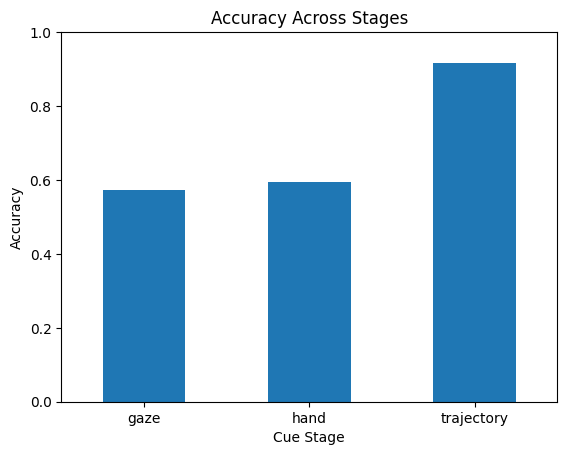

In [22]:
stage_accuracy.plot(kind="bar")
plt.title("Accuracy Across Stages")
plt.xlabel("Cue Stage")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## Final Accuracy per Experiment

In [23]:
final_stage = df[df["stage"] == "trajectory"]
final_accuracy = final_stage.groupby("experiment")["correct"].mean()
final_accuracy

experiment
all_cues_correct_large                              0.92
all_cues_correct_small                              0.90
gaze_and_hand_wrong_trajectory_correct_small        0.90
gaze_correct_hand_wrong_trajectory_correct_large    0.94
gaze_wrong_hand_trajectory_correct_small            0.92
Name: correct, dtype: float64

Final accuracy differs across experimental conditions, particularly when early cues are misleading. This indicates that cue conflict affects prediction performance.

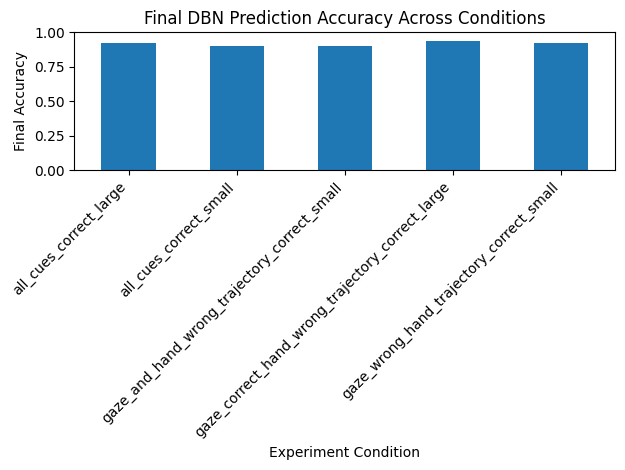

In [24]:
final_accuracy.plot(kind="bar")
plt.title("Final DBN Prediction Accuracy Across Conditions")
plt.xlabel("Experiment Condition")
plt.ylabel("Final Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Belief Evolution (Single Condition)

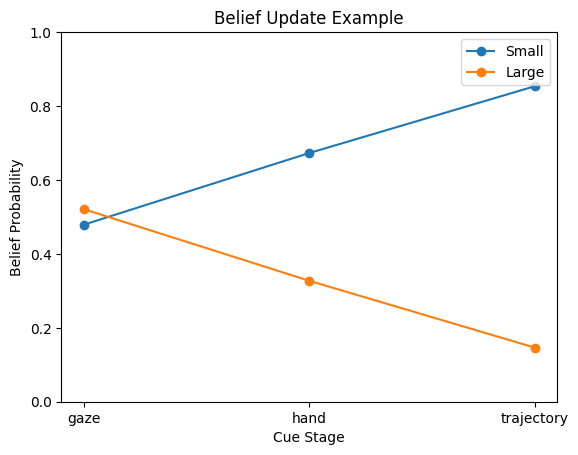

In [25]:
exp = df[df["experiment"] == "gaze_wrong_hand_trajectory_correct_small"]

exp_mean = exp.groupby("stage")[["small_prob", "large_prob"]].mean()
exp_mean = exp_mean.reindex(["gaze", "hand", "trajectory"])

plt.plot(exp_mean.index, exp_mean["small_prob"], marker="o", label="Small")
plt.plot(exp_mean.index, exp_mean["large_prob"], marker="o", label="Large")

plt.legend()
plt.title("Belief Update Example")
plt.xlabel("Cue Stage")
plt.ylabel("Belief Probability")
plt.ylim(0, 1)
plt.show()

The belief changes across stages, showing that the model updates its prediction as new information becomes available. Early cues may bias the prediction, which is corrected as stronger cues are incorporated.

## Belief Evolution Across All Conditions (Small Object)

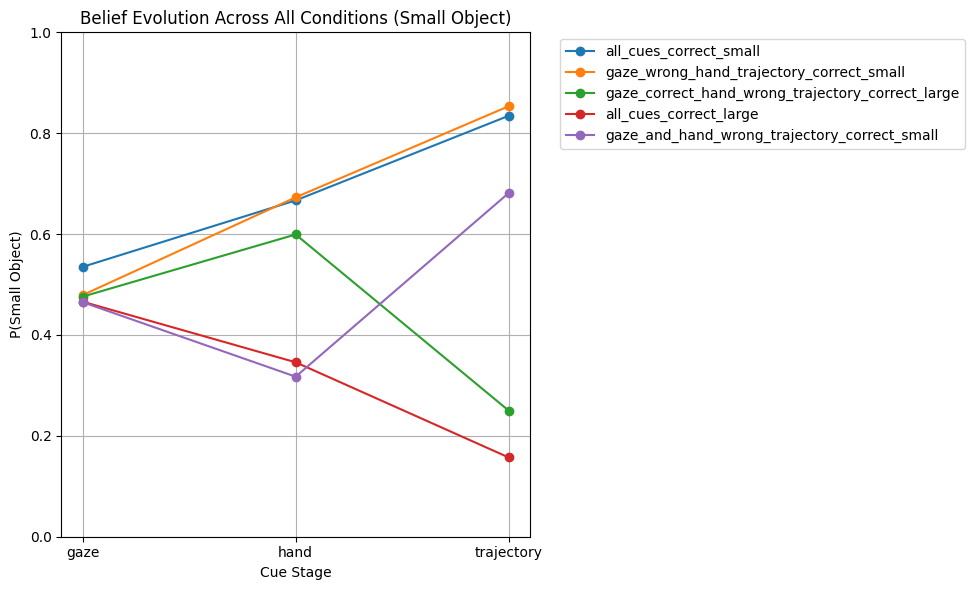

In [26]:
def plot_all_beliefs_small(df):
    experiments = df["experiment"].unique()

    plt.figure(figsize=(10, 6))

    for exp in experiments:
        subset = df[df["experiment"] == exp]

        mean_vals = subset.groupby("stage")[["small_prob"]].mean()
        mean_vals = mean_vals.reindex(["gaze", "hand", "trajectory"])

        plt.plot(mean_vals.index, mean_vals["small_prob"], marker="o", label=exp)

    plt.title("Belief Evolution Across All Conditions (Small Object)")
    plt.xlabel("Cue Stage")
    plt.ylabel("P(Small Object)")
    plt.ylim(0, 1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_all_beliefs_small(df)

The results show that belief trajectories differ in early stages depending on cue reliability. However, as more informative cues are incorporated, the belief converges towards the correct target.

This demonstrates that the model is capable of correcting early misinterpretations through temporal integration of information.

## Belief Evolution Across All Conditions (Large Object)

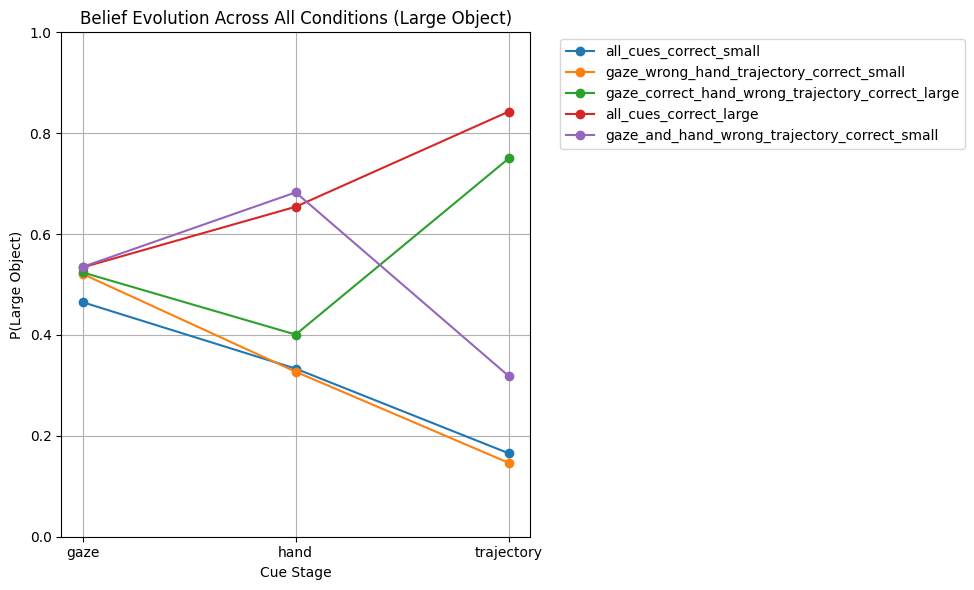

In [27]:
def plot_all_beliefs_large(df):
    experiments = df["experiment"].unique()

    plt.figure(figsize=(10, 6))

    for exp in experiments:
        subset = df[df["experiment"] == exp]

        mean_vals = subset.groupby("stage")[["large_prob"]].mean()
        mean_vals = mean_vals.reindex(["gaze", "hand", "trajectory"])

        plt.plot(mean_vals.index, mean_vals["large_prob"], marker="o", label=exp)

    plt.title("Belief Evolution Across All Conditions (Large Object)")
    plt.xlabel("Cue Stage")
    plt.ylabel("P(Large Object)")
    plt.ylim(0, 1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_all_beliefs_large(df)

The belief for the large object follows an inverse pattern to the small object, reflecting the binary nature of the prediction task. As confidence in one hypothesis increases, confidence in the alternative decreases.

Together, the small-object and large-object belief plots illustrate how the model redistributes probability between competing hypotheses as new evidence is incorporated over time.

## Effect of Noise

In [28]:
df["noisy_change"] = (df["observation"] != df["noisy_observation"]).astype(int)

noise_by_stage = df.groupby("stage")["noisy_change"].mean()
noise_by_stage = noise_by_stage.reindex(["gaze", "hand", "trajectory"])

noise_by_stage

stage
gaze          0.202
hand          0.130
trajectory    0.084
Name: noisy_change, dtype: float64

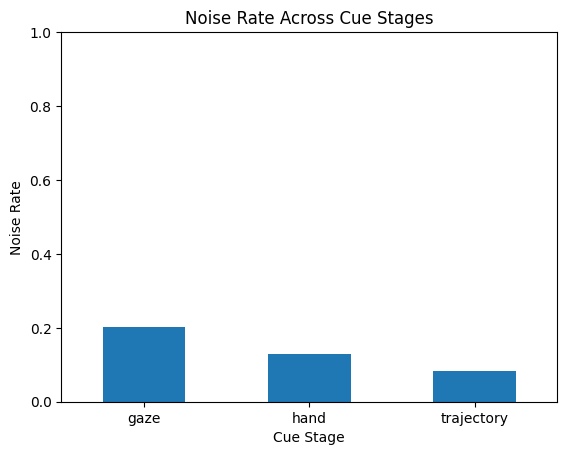

In [29]:
noise_by_stage.plot(kind="bar")
plt.title("Noise Rate Across Cue Stages")
plt.xlabel("Cue Stage")
plt.ylabel("Noise Rate")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

Noise introduces variability in the observed cues, preventing deterministic predictions and making the model more realistic. The noise analysis quantifies how often original cues are altered before being processed by the DBN.

The results show that noise varies across cue stages, with gaze exhibiting the highest noise rate, followed by hand, and trajectory showing the lowest. This supports the assumption that early perceptual cues are less reliable, while later motor cues are more stable and informative.

The reduction in noise across stages contributes to the observed increase in prediction accuracy, particularly at the trajectory stage. This pattern aligns with human cognition, where initial perceptual signals are often ambiguous and confidence improves as more reliable information becomes available.

## Reliability Analysis

In [30]:
reliability_cols = ["gaze_reliability", "hand_reliability", "trajectory_reliability"]
available_cols = [col for col in reliability_cols if col in df.columns]

if available_cols:
    df.groupby("stage")[available_cols].mean()
else:
    print("Reliability tracking not available in current results.")

Reliability tracking not available in current results.


Reliability values were not explicitly stored in the results file. However, the DBN model internally uses cue reliability values during belief updating, and the learning rule updates these values during each trial.

Future work could store these reliability values at each stage to analyse how the model adapts trust in gaze, hand, and trajectory cues over time.

## Discussion

The results show that the Dynamic Bayesian Network (DBN) is able to capture key aspects of human action prediction described in *The eye in hand: predicting others’ behaviour by integrating multiple sources of information* (Ambrosini, Pezzulo, & Costantini, 2015).

### Comparison with the Original Study

The original study demonstrates that humans combine different cues such as gaze, hand preshape, and trajectory over time, and that the importance of each cue depends on its reliability. Gaze tends to influence early predictions, but as the action progresses, more informative motor cues such as hand preshape and trajectory become more important (Ambrosini, Pezzulo, & Costantini, 2015).

The behaviour of the DBN is broadly consistent with these findings:

- **Early gaze influence:** Initial predictions are influenced by gaze information  
- **Motor cue dominance:** Accuracy increases from gaze to hand to trajectory, showing that later cues are more reliable  
- **Conflict resolution:** Incorrect early predictions are corrected when stronger cues are observed  
- **Temporal integration:** The model updates its belief step by step as new information becomes available  

However, unlike human participants, the DBN follows a near-optimal Bayesian approach and does not show biases such as over-reliance on hand preshape (often referred to as hyperpriors), which have been reported in human behaviour (Ambrosini, Pezzulo, & Costantini, 2015).

### Interpretation

These results suggest that action prediction can be modelled as a Bayesian inference process, where different sources of information are combined and updated over time. The model shows how predictions can change as more reliable evidence becomes available, which is similar to how humans interpret actions in real-world situations.

### Limitations

- The model does not learn or update cue reliability over time  
- Human biases such as hyperpriors are not represented  
- Observations are simplified as discrete values rather than continuous sensory input  
- Reaction time and gaze behaviour are not modelled  
- The model does not fully capture variability in human responses  

### Future Work

- Introduce learning mechanisms to update cue reliability  
- Incorporate human-like biases such as hyperpriors  
- Extend the model to handle continuous perception  
- Combine the DBN with reinforcement learning  
- Apply the model in a real robotic system using vision-based inputs  

### Conclusion

Overall, the DBN provides a useful framework for modelling how multiple cues are integrated during action prediction. While it reproduces key patterns observed in the study, further improvements are needed to better reflect the complexity of human cognition and behaviour.